# Day 08. Exercise 04
# Regression

## 0. Imports

In [158]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [159]:
df = pd.read_csv('../data/checker_regression.csv')

In [160]:
df.isna().sum()

uid             0
num_commits     0
pageviews      18
AVG(diff)      59
dtype: int64

In [161]:
df = df.fillna(0)

In [162]:
df = df.set_index('uid')

In [163]:
df

,num_commits,pageviews,AVG(diff)
uid,,,
user_1,62,28.0,0.00
user_1,62,28.0,0.00
user_1,62,28.0,0.00
user_1,62,28.0,0.00
user_1,62,28.0,0.00
...,...,...,...
user_31,128,0.0,-104.75
user_4,40,0.0,-175.60
user_6,15,0.0,-62.60


In [164]:
X = df.drop('AVG(diff)', axis=1)

In [165]:
y = df['AVG(diff)']

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [167]:
'''
k_fold = KFold(n_splits=3, random_state=21, shuffle=True)
k_fold.split(X)

for train_index, test_index in k_fold.split(X):
        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]
        print(X_train)
        print(X_test)
        print(y_train)
        print(y_test)
'''

'\nk_fold = KFold(n_splits=3, random_state=21, shuffle=True)\nk_fold.split(X)\n\nfor train_index, test_index in k_fold.split(X):\n        X_train = X.iloc[train_index]\n        X_test = X.iloc[test_index]\n        y_train = y.iloc[train_index]\n        y_test = y.iloc[test_index]\n        print(X_train)\n        print(X_test)\n        print(y_train)\n        print(y_test)\n'

In [168]:
def crossval(n_splits, X, y, model):
    k_fold = KFold(n_splits=n_splits, random_state=21, shuffle=True)
    test_scores = []
    
    for train_index, test_index in k_fold.split(X):
        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]
    
        model.fit(X_train, y_train)
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        curr_train_score = np.sqrt(mean_squared_error(y_train, train_pred))
        curr_test_score = np.sqrt(mean_squared_error(y_test, test_pred))
        
        test_scores.append(curr_test_score)
    
        print(f'train -  {curr_train_score}   |   test -  {curr_test_score}')
    
    print(f'Average RMSE on crossval is {np.mean(test_scores)}')

In [169]:
## crossval for LinearRegression
lr = LinearRegression()
crossval(10, X, y, lr)

train -  42.27291015233797   |   test -  70.43979397280242
train -  47.45726648237968   |   test -  30.657394014354043
train -  47.77854388604299   |   test -  27.137319378269105
train -  46.2441901620785   |   test -  44.12307205209637
train -  46.39355004742244   |   test -  42.420391728163665
train -  47.715419148024964   |   test -  28.273391654514054
train -  46.308918660456506   |   test -  45.67313727400561
train -  47.81194647242181   |   test -  20.572476580923418
train -  44.12915324532897   |   test -  63.14957718941946
train -  42.350893141368886   |   test -  74.1589333008101
Average RMSE on crossval is 44.66054871453582


In [170]:
## crossval for DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=21, max_depth=1)
crossval(10, X, y, dt)

train -  25.880997916233767   |   test -  55.697392555666376
train -  32.08012635514713   |   test -  0.8620463552994719
train -  32.081394602317864   |   test -  0.0
train -  31.475440793059008   |   test -  18.753927645146163
train -  31.052844998507652   |   test -  23.76595293653257
train -  30.113743972078822   |   test -  33.43055280642105
train -  30.244320460023015   |   test -  32.15217116245914
train -  30.853993063381314   |   test -  25.733822310854702
train -  29.95690497384943   |   test -  34.4405634758847
train -  28.81650709404577   |   test -  45.47979538767149
Average RMSE on crossval is 27.031622463593568


In [171]:
## crossval for RandomForestRegressor
rf = RandomForestRegressor(random_state=21, max_depth=1, n_estimators=100)
crossval(10, X, y, rf)

train -  25.88123215241426   |   test -  55.68759928130762
train -  32.09817971693908   |   test -  1.6287512909288062
train -  32.083480703518944   |   test -  0.0
train -  31.49481628774158   |   test -  17.967155050165843
train -  31.07581088864619   |   test -  24.166456042423818
train -  30.113862303803934   |   test -  33.370421105256526
train -  30.245692698174054   |   test -  32.18843111437664
train -  30.863538981922037   |   test -  25.145129574941194
train -  30.022043250227693   |   test -  33.79462359691242
train -  28.82136183630365   |   test -  44.89181757830699
Average RMSE on crossval is 26.884038463461984


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [172]:
## LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)

<AxesSubplot: xlabel='AVG(diff)'>

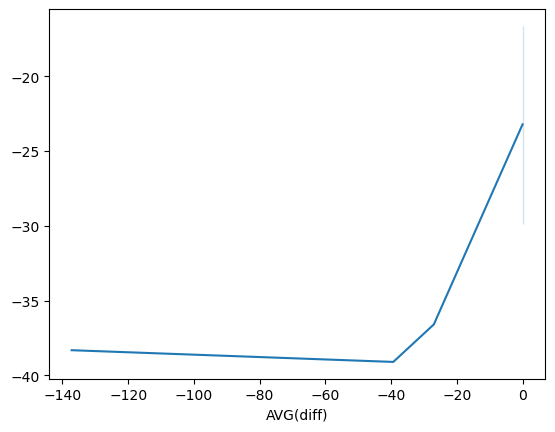

In [173]:
sns.lineplot(x=y_test, y=pred)

In [174]:
## DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state=21, max_depth=1)
dt.fit(X_train, y_train)
pred = dt.predict(X_test)

<AxesSubplot: xlabel='AVG(diff)'>

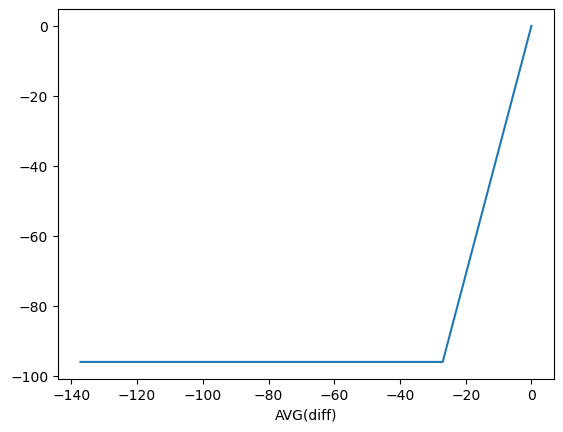

In [175]:
sns.lineplot(x=y_test, y=pred)

In [176]:
## RandomForestRegressor
rf = RandomForestRegressor(random_state=21, max_depth=10, n_estimators=100)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

<AxesSubplot: xlabel='AVG(diff)'>

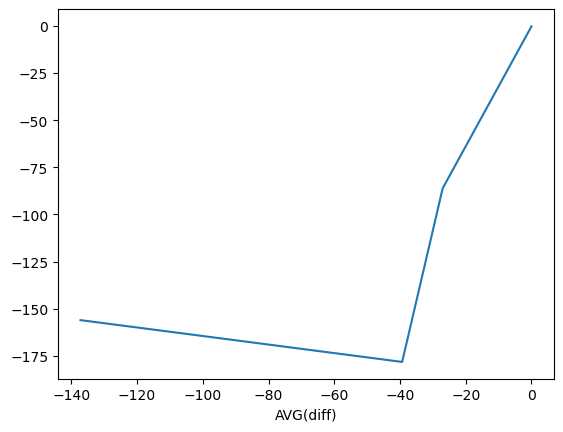

In [177]:
sns.lineplot(x=y_test, y=pred)

#### How would plot look like in the ideal case?

<AxesSubplot: xlabel='AVG(diff)', ylabel='AVG(diff)'>

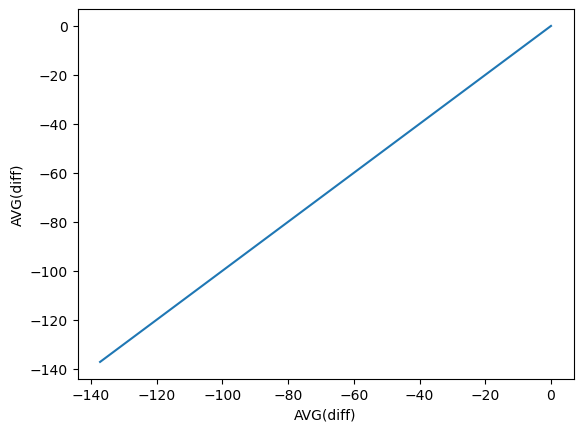

In [178]:
sns.lineplot(x=y_test, y=y_test)

Answer: diagonal (y = x).